# **1. Sumber Dataset**:  
   Dataset ini merupakan dataset yang saya peroleh langsung dari PLN Banjar Negara, JAwa Tengah. Dataset INFLOW.csv ini merupakan data terkait INFLOW bendungan di PLN Banjar Negara, Jawa Tengah. Dataset ini memiliki dua variabel yaitu datetime dan INFLOW. INFLOW merupakan volume air yang masuk ke bendungan yang digunakan untuk menggerakan turbin, sedangkan datetime menunjukkan tanggal dan waktu. Dataset seperti ini, biasa dikenal dengan timeseries dataset.


# **2. Import Library**

Pada tahap ini, dilakukan import beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from sklearn.preprocessing import MinMaxScaler


import matplotlib.pyplot as plt
import seaborn as sns

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('/content/inflow.csv')
df.index = pd.to_datetime(df['datetime'], format='mixed')
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000 entries, 2024-06-29 01:00:00 to 2024-11-01 00:00:00
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     3000 non-null   object 
 1   INFLOW       3000 non-null   float64
 2   hour         3000 non-null   int32  
 3   day_of_week  3000 non-null   int32  
 4   month        3000 non-null   int32  
dtypes: float64(1), int32(3), object(1)
memory usage: 105.5+ KB


In [4]:
df.describe()

,INFLOW,hour,day_of_week,month
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,28.416000,11.500000,2.991667,8.457667
std,24.730079,6.923341,2.006059,1.156137
min,7.000000,0.000000,0.000000,6.000000
25%,16.000000,5.750000,1.000000,7.000000
50%,22.000000,11.500000,3.000000,8.000000
75%,32.000000,17.250000,5.000000,9.000000
max,474.000000,23.000000,6.000000,11.000000


In [5]:
dataNull = df.isnull().sum()
dataNull

,0
datetime,0
INFLOW,0
hour,0
day_of_week,0
month,0


In [6]:
null_rows = df[df.isnull().any(axis=1)].index
print("Baris dengan nilai NaN:", null_rows.tolist())

Baris dengan nilai NaN: []


In [7]:
# Checking for data duplication
any(df.duplicated())

False

### Univariate Analysis
Unvariate analysis is performed to determine the distribution of each variable in the dataset. This process produces a visualization that illustrates the comparison of distributions on each variable in the dataset.

In [8]:
numerical_features = ['INFLOW']

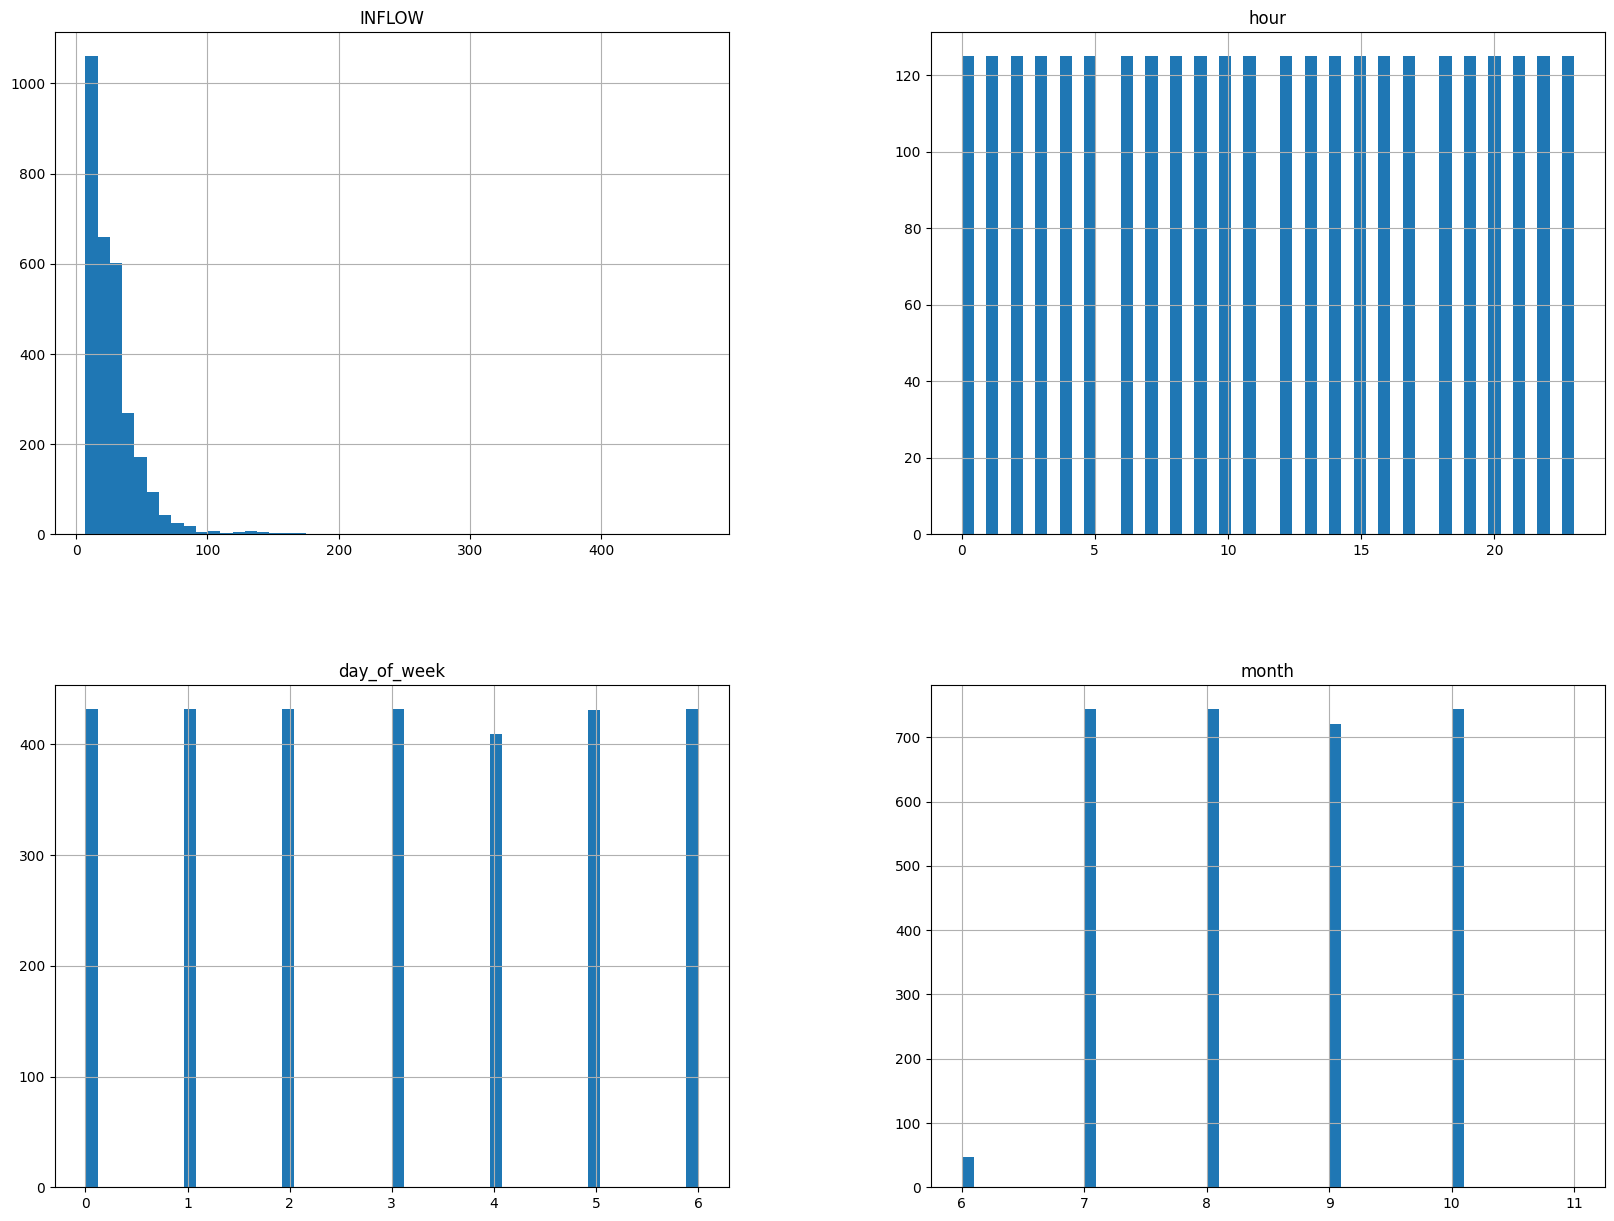

In [9]:
df.hist(bins=50, figsize=(20,15))
plt.show()

<Axes: xlabel='datetime'>

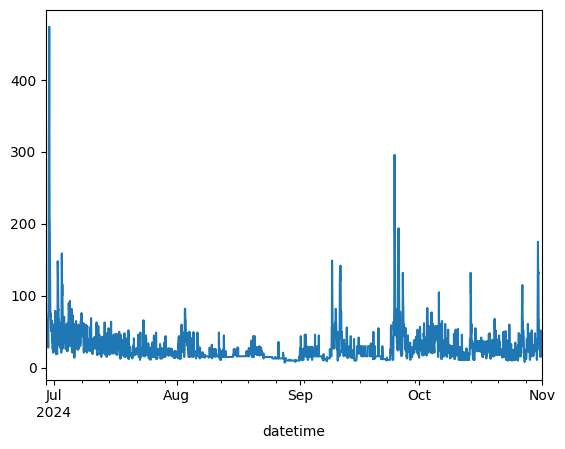

In [10]:
inflow_df = df['INFLOW']
inflow_df.plot()

In [11]:
datetime = df['datetime'].values
inflow  = df['INFLOW'].values

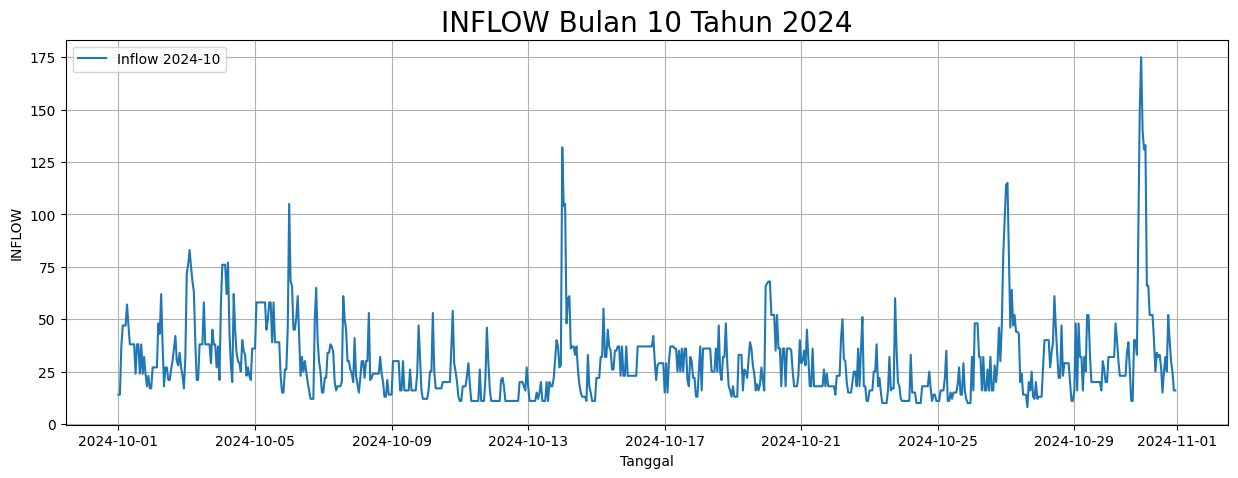

In [12]:
tahun = 2024
bulan = 10 # Ganti dengan 7, 8, atau 9 jika bulan 10 kosong
variabel = 'INFLOW'
# Pastikan kolom datetime sudah dalam format datetime
df["datetime"] = pd.to_datetime(df["datetime"])
# Filter berdasarkan tahun DAN bulan
df_filtered = df[(df["datetime"].dt.year == tahun) & (df["datetime"].dt.month == bulan)]
# Ambil nilai datetime dan inflow
datetime_filtered = df_filtered["datetime"].values
inflow_filtered = df_filtered[variabel].values
# Plot datanya
plt.figure(figsize=(15, 5))
plt.plot(datetime_filtered, inflow_filtered, label=f"Inflow {tahun}-{bulan:02d}")
plt.title(f"{variabel} Bulan {bulan} Tahun {tahun}", fontsize=20)
plt.xlabel("Tanggal")
plt.ylabel(f"{variabel}")
plt.legend()
plt.grid(True)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
df.set_index('datetime', inplace=True)

In [14]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

imputer = SimpleImputer(strategy='median')
columns_to_process = ['INFLOW']

for col in columns_to_process:
    df[col] = imputer.fit_transform(df[[col]])

Missing values before preprocessing:
INFLOW         0
hour           0
day_of_week    0
month          0
dtype: int64


In [15]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in columns_to_process:
    df = remove_outliers(df, col)

In [16]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

In [17]:
feature_columns = ['INFLOW', 'hour', 'day_of_week', 'month']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[feature_columns])
joblib.dump(scaler, f"scaler_INFLOW.pkl")

['scaler_INFLOW.pkl']

In [18]:
target_column='INFLOW'
look_back=168
output_steps=168

In [19]:
X, y = [], []
target_col_index = feature_columns.index(target_column)

for i in range(len(scaled_data) - look_back - output_steps):
    X.append(scaled_data[i:i+look_back])
    y.append(scaled_data[i+look_back:i+look_back+output_steps, target_col_index])

X = np.array(X)
y = np.array(y)
y = y.reshape((y.shape[0], y.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:

os.makedirs('../dataset', exist_ok=True)

X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
y_train_reshaped = y_train.reshape(y_train.shape[0], -1)
y_test_reshaped = y_test.reshape(y_test.shape[0], -1)

pd.DataFrame(X_train_reshaped).to_csv('../dataset/X_train.csv', index=False)
pd.DataFrame(X_test_reshaped).to_csv('../dataset/X_test.csv', index=False)
pd.DataFrame(y_train_reshaped).to_csv('../dataset/y_train.csv', index=False)
pd.DataFrame(y_test_reshaped).to_csv('../dataset/y_test.csv', index=False)

print("Dataset berhasil disimpan ke folder dataset!")


Dataset berhasil disimpan ke folder dataset!
